## **Conflict Panel Window Generator**

In this notebook, we are going to generate a cutted panel dataset to feed csdid. For that we are going to work with a monthly conflict panel dataset that contains information about fatalities and treatment status (peace agreement signed or not) at the conflict level.

Steps:

1. Load the panel dataset already generated at conflict level with monthly frequency.
2. Generate some columns needed for the <code>WindowGenerator</code> class.
3. Instantiate the <code>WindowGenerator</code> class with the desired parameters to generate a balanced panel dataset.
4. Export the windows dataset to a csv file for later use in the causal effect estimation with <code>csdid</code>.

Units of this panel are the <code>conflict_id</code> and time in months (<code>year_mo</code>).

In [14]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from window_generator import WindowGenerator
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../')))

In [15]:
df= pd.read_csv(f'../../../../data/output/country_level/country_panel.csv')

In [16]:
treatment_vars = ['ceasfire_agreements_mentions', 'treated_ceasfire_agreements_mentions',
                  'agreement_no_ceasefire','treated_agreements_no_ceasefire', 'agreement_no_ceasefire_mentions_agreement_6m',
                  'comp_agreement_no_ceasefire','treated_comp_agreements_no_ceasefire', 'comp_agreement_no_ceasefire_mentions_agreement_6m',
                  'subs_agreement_no_ceasefire','treated_subs_agreements_no_ceasefire', 'subs_agreement_no_ceasefire_mentions_agreement_6m']

#Mechanism features
#----------------------------
info_vars = ['ceprov', 'cegen', 'ele', 'eleccomm',
             'hrni','hrii','hriimon','hriibod',
             'med', 'medgov', 'medsubs',
             'medlog', 'civso', 'hrmob', 'tjmech', 'tjmis']

commit_vars = ['polps', 'ppsex', 'ppsoro', 'ppsvet','ppsaut', 'ppsothpr','ppsint',
               'terps', 'tpssub', 'tpsloc', 'tpsaut','tpsoth',
               'eps', 'epsres', 'epsfis', 'epsoth',
               'mps', 'mpsme', 'mpsjt', 'mpspro',
               'ssrpol', 'ssrarm', 'ssrddr', 'ddrdemil','ddrprog','ssrgua',
               'impk', 'ime', 'imun', 'imoth', 'imref',
               'pol', 'polnewind', 'polnewtemp', 'ele','eleccomm', 'polpar']

cost_vars = ['ssrddr', 'ddrprog', 'ddrdemil', 'ddrprog',
              'tjcou', 'tjamban', 'tjvet', 'tjrep', 'tjvic',
             'prot', 'protciv', 'protgrp']


check_balances_vars = ['hrni', 'hrii', 'hrbor', 'hrdem', 'hrtrinc', 'juscr', 'polpar',
                       'pubad']
features_cluster_columns = list(set(info_vars + commit_vars + cost_vars + check_balances_vars))


df = df[['year_mo_numeric', 'isocode','isocode_num', 'region_num', 'region', 'subregion', 
         'year_mo','log_best','best', 
        'treated_agreement', 'agreement','first_agreement_date',  
        'treated_comp_agreement','comp_agreement', 'first_comp_agreement_date',
        'subs_agreement', 'treated_subs_agreement', 'first_subs_agreement_date',
        'cea_agreement', 'treated_cea_agreement', 'first_cea_agreement_date',
        'cea_ceas_agreement', 'treated_cea_ceas_agreement', 'first_cea_ceas_agreement_date',
        'cea_rel_agreement', 'treated_cea_rel_agreement', 'first_cea_rel_agreement_date',
        'cea_ceamix_agreement', 'treated_cea_ceamix_agreement', 'first_cea_ceamix_agreement_date',
        'ce', 'real_observation', 'gdp_pc_current_usd', 'log_gdp_pc_current_usd'
        ]+ treatment_vars+ features_cluster_columns]

#Define some control variables to use in the regressions
for i in range(1,7):
        df[f'log_best_lag{i}'] = df.groupby('isocode')['log_best'].shift(i)
        df[f'log_gdp_pc_current_usd_lag{i}'] = df.groupby('isocode')['log_gdp_pc_current_usd'].shift(i)
        
#rolling mean of past 3 months
df['log_best_rolling_mean_3m'] = df.groupby('isocode')['log_best'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

### **Define treatment variables**

In [17]:
# Time period factorization
# ================================================================================
df['year_mo'] = pd.to_datetime(df['year_mo'])
df[f'isocode_t'] = df.groupby('isocode').year_mo.transform(lambda x: pd.factorize(x, sort=True)[0])
df = df.sort_values(['isocode', 'year_mo'])  # make sure data is sorted correctly

df['log_best_lag1'] = df.groupby('isocode')['log_best'].shift(1)
df['gdp_pc_current_usd_lag1'] = df.groupby('isocode')['gdp_pc_current_usd'].shift(1)
df 

,year_mo_numeric,isocode,isocode_num,region_num,region,subregion,year_mo,log_best,best,treated_agreement,...,log_gdp_pc_current_usd_lag3,log_best_lag4,log_gdp_pc_current_usd_lag4,log_best_lag5,log_gdp_pc_current_usd_lag5,log_best_lag6,log_gdp_pc_current_usd_lag6,log_best_rolling_mean_3m,isocode_t,gdp_pc_current_usd_lag1
0,1,AFG,1,3,Asia,Southern Asia,1989-01-01,6.543552,693.75,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.543552,0,NaN
1,2,AFG,1,3,Asia,Southern Asia,1989-02-01,5.098341,162.75,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.820946,1,NaN
2,3,AFG,1,3,Asia,Southern Asia,1989-03-01,7.465512,1745.75,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.369135,2,NaN
3,4,AFG,1,3,Asia,Southern Asia,1989-04-01,6.208087,495.75,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.257313,3,NaN
4,5,AFG,1,3,Asia,Southern Asia,1989-05-01,6.091310,441.00,1.0,...,NaN,6.543552,NaN,NaN,NaN,NaN,NaN,6.588303,4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46651,428,ZAF,108,1,Africa,Sub-Saharan Africa,2024-08-01,0.000000,0.00,0.0,...,8.739981,0.000000,8.736870,0.0,8.733748,0.0,8.730617,0.000000,427,NaN
46652,429,ZAF,108,1,Africa,Sub-Saharan Africa,2024-09-01,0.000000,0.00,0.0,...,8.743083,0.000000,8.739981,0.0,8.736870,0.0,8.733748,0.000000,428,NaN
46653,430,ZAF,108,1,Africa,Sub-Saharan Africa,2024-10-01,0.000000,0.00,0.0,...,NaN,0.000000,8.743083,0.0,8.739981,0.0,8.736870,0.000000,429,NaN
46654,431,ZAF,108,1,Africa,Sub-Saharan Africa,2024-11-01,0.000000,0.00,0.0,...,NaN,0.000000,NaN,0.0,8.743083,0.0,8.739981,0.000000,430,NaN


## **Generate windows**

In [18]:
treatment = 'ceasfire_agreements_mentions'
frame_size   = [18, 18] # how large of a window 'frame' to sample
buffer_size_treated  = [18, 1]  # months since treatment and until treatment
buffer_size_control = [18, 18]  # months since treatment and until treatment

In [19]:
wg = WindowGenerator(dataframe = df,
                     frame_size = frame_size,
                     unit_column = 'isocode',
                     time_column = 'isocode_t',
                     treatment_column = treatment,
                     )

In [20]:
wg.generate_treatment_windows(buffer_size=buffer_size_treated)

=== Potential Windows Generation Summary ===
---> Total possible windows found: 536
---> Excluded 25 units/times due to insufficient data (frame size requirement).
---> Excluded windw_id's (unit_time): ['COD_419', 'COD_426', 'COD_429', 'COL_414', 'COL_415', 'COL_416', 'COL_417', 'COL_419', 'COL_420', 'COL_421', 'COL_422', 'COL_423', 'COL_424', 'COL_426', 'COL_429', 'GTM_17', 'ISR_430', 'LBN_430', 'MLI_430', 'NIC_14', 'NIC_15', 'SDN_418', 'SDN_420', 'SSD_424', 'YEM_421']
Generated 511 windows.
=== Windows Buffer Checking Summary ===
Generated 112 valid windows.
=== Windows Continuity Checking Summary ===
Generated 112 valid continuous windows.


In [21]:
wg.treated_windows.window_id.nunique()

112

In [22]:
matching_method='random'
wg.generate_control_windows(buffer_size=buffer_size_control, k=5, t=1, 
                            matching_method=matching_method
                            )

=== Potential Windows Generation Summary ===
---> Total possible windows found: 46120
---> Excluded 3863 units/times due to insufficient data (frame size requirement).
---> Excluded windw_id's (unit_time): ['AFG_0', 'AFG_1', 'AFG_2', 'AFG_3', 'AFG_4', 'AFG_5', 'AFG_6', 'AFG_7', 'AFG_8', 'AFG_9', 'AFG_10', 'AFG_11', 'AFG_12', 'AFG_13', 'AFG_14', 'AFG_15', 'AFG_16', 'AFG_17', 'AFG_414', 'AFG_415', 'AFG_416', 'AFG_417', 'AFG_418', 'AFG_419', 'AFG_420', 'AFG_421', 'AFG_422', 'AFG_423', 'AFG_424', 'AFG_425', 'AFG_426', 'AFG_427', 'AFG_428', 'AFG_429', 'AFG_430', 'AFG_431', 'AGO_0', 'AGO_1', 'AGO_2', 'AGO_3', 'AGO_4', 'AGO_5', 'AGO_6', 'AGO_7', 'AGO_8', 'AGO_9', 'AGO_10', 'AGO_11', 'AGO_12', 'AGO_13', 'AGO_14', 'AGO_15', 'AGO_16', 'AGO_17', 'AGO_414', 'AGO_415', 'AGO_416', 'AGO_417', 'AGO_418', 'AGO_419', 'AGO_420', 'AGO_421', 'AGO_422', 'AGO_423', 'AGO_424', 'AGO_425', 'AGO_426', 'AGO_427', 'AGO_428', 'AGO_429', 'AGO_430', 'AGO_431', 'ALB_0', 'ALB_1', 'ALB_2', 'ALB_3', 'ALB_4', 'ALB_5', 'AL

In [23]:
wg.control_windows.window_id.nunique()

560

In [24]:
df_clean = wg.combined_windows
df_clean['window_id_num'] = df_clean['window_id'].astype('category').cat.codes
df_clean

,year_mo_numeric,isocode,isocode_num,region_num,region,subregion,year_mo,log_best,best,treated_agreement,...,log_best_lag6,log_gdp_pc_current_usd_lag6,log_best_rolling_mean_3m,isocode_t,gdp_pc_current_usd_lag1,window_id,window_t,is_treated_window,matched_treated_window_id,window_id_num
0,33,AFG,1,3,Asia,Southern Asia,1991-09-01,3.646320,37.333333,1.0,...,6.887893,NaN,4.621382,32,NaN,AFG_50,-18,1,NaN,5
1,34,AFG,1,3,Asia,Southern Asia,1991-10-01,5.422009,225.333333,1.0,...,7.003368,NaN,4.948488,33,NaN,AFG_50,-17,1,NaN,5
2,35,AFG,1,3,Asia,Southern Asia,1991-11-01,5.641316,280.833333,1.0,...,5.351068,NaN,4.903215,34,NaN,AFG_50,-16,1,NaN,5
3,36,AFG,1,3,Asia,Southern Asia,1991-12-01,3.251666,24.833333,1.0,...,3.361532,NaN,4.771663,35,NaN,AFG_50,-15,1,NaN,5
4,37,AFG,1,3,Asia,Southern Asia,1992-01-01,0.000000,0.000000,1.0,...,4.440689,NaN,2.964327,36,NaN,AFG_50,-14,1,NaN,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24859,218,LSO,56,1,Africa,Sub-Saharan Africa,2007-02-01,0.000000,0.000000,0.0,...,0.000000,6.818656,0.000000,217,887.971364,LSO_203,14,0,YEM_385,340
24860,219,LSO,56,1,Africa,Sub-Saharan Africa,2007-03-01,0.000000,0.000000,0.0,...,0.000000,6.812783,0.000000,218,882.614776,LSO_203,15,0,YEM_385,340
24861,220,LSO,56,1,Africa,Sub-Saharan Africa,2007-04-01,0.000000,0.000000,0.0,...,0.000000,6.806875,0.000000,219,877.258187,LSO_203,16,0,YEM_385,340
24862,221,LSO,56,1,Africa,Sub-Saharan Africa,2007-05-01,0.000000,0.000000,0.0,...,0.000000,6.800932,0.000000,220,871.901598,LSO_203,17,0,YEM_385,340


### **Dessagregating by conflict intensity**

Looking at the levels of violence preagreement $window_t = [-18, 0]$, take the $median(\sum_{w_t = -18}^{0}log\_best)$ and define:

- high intensity conflicts: those with $\sum_{w_t = -18}^{0}log\_best>$  the median
- low intensity conflicts: those with $\sum_{w_t = -18}^{0}log\_best<$  the median

In [25]:
# 1 Filter only treated windows within the period -18 to 0
pre_sum = (
    df_clean[df_clean['window_t'].between(-18, 0)]
    .groupby('window_id')['log_best']
    .sum()
)
pre_sum.name = 'pre_sum_log_best'

# 2 Merge result to dataframe (constant broadcast by window_id)
df_clean = df_clean.merge(pre_sum, on='window_id', how='left')

# 3 Calculate median only for treated
median_sum = df_clean.loc[df_clean['is_treated_window'] == 1, 'pre_sum_log_best'].median()

# 4 Create intensity variable
df_clean['intensity_level'] = 'control'
mask_treated = df_clean['is_treated_window'] == 1
df_clean.loc[mask_treated & (df_clean['pre_sum_log_best'] > median_sum), 'intensity_level'] = 'high_intensity'
df_clean.loc[mask_treated & (df_clean['pre_sum_log_best'] <= median_sum), 'intensity_level'] = 'low_intensity'

df_clean.loc[df_clean['is_treated_window']==1][['isocode', 'year_mo', 'log_best', 'window_id','window_t', 'pre_sum_log_best', 'intensity_level']]

,isocode,year_mo,log_best,window_id,window_t,pre_sum_log_best,intensity_level
0,AFG,1991-09-01,3.646320,AFG_50,-18,84.473053,high_intensity
1,AFG,1991-10-01,5.422009,AFG_50,-17,84.473053,high_intensity
2,AFG,1991-11-01,5.641316,AFG_50,-16,84.473053,high_intensity
3,AFG,1991-12-01,3.251666,AFG_50,-15,84.473053,high_intensity
4,AFG,1992-01-01,0.000000,AFG_50,-14,84.473053,high_intensity
...,...,...,...,...,...,...,...
4139,YEM,2022-04-01,4.685982,YEM_385,14,110.116827,high_intensity
4140,YEM,2022-05-01,4.101265,YEM_385,15,110.116827,high_intensity
4141,YEM,2022-06-01,3.996670,YEM_385,16,110.116827,high_intensity
4142,YEM,2022-07-01,4.470686,YEM_385,17,110.116827,high_intensity


In [26]:
df_clean.loc[df_clean['is_treated_window']==0][['isocode', 'year_mo', 'log_best', 'window_id', 'window_t', 'is_treated_window','pre_sum_log_best', 'intensity_level']]

,isocode,year_mo,log_best,window_id,window_t,is_treated_window,pre_sum_log_best,intensity_level
4144,RWA,2019-02-01,0.0,RWA_379,-18,0,2.995732,control
4145,RWA,2019-03-01,0.0,RWA_379,-17,0,2.995732,control
4146,RWA,2019-04-01,0.0,RWA_379,-16,0,2.995732,control
4147,RWA,2019-05-01,0.0,RWA_379,-15,0,2.995732,control
4148,RWA,2019-06-01,0.0,RWA_379,-14,0,2.995732,control
...,...,...,...,...,...,...,...,...
24859,LSO,2007-02-01,0.0,LSO_203,14,0,0.000000,control
24860,LSO,2007-03-01,0.0,LSO_203,15,0,0.000000,control
24861,LSO,2007-04-01,0.0,LSO_203,16,0,0.000000,control
24862,LSO,2007-05-01,0.0,LSO_203,17,0,0.000000,control


In [27]:
df_clean.loc[df_clean['intensity_level']=='low_intensity']['window_id'].nunique()

56

### **Mechanisms variables**
---


In [28]:
#A. Reduce information asymmetries
info_vars = [#'ceprov', 'cegen', 
             'ele', 'eleccomm', #Electoral & political info
             'hrni','hrii','hriimon','hriibod', #Rights monitoring bodies:
             'med', 'medgov', 'medsubs','medlog',  #Media + civil society
             'civso', # Civil Society inclusion
             'hrmob', #Mobility for observers/humanitarians
             'tjmech', 'tjmis' #Transitional-justice mechanisms that surface facts
             ] 
#B. Build commitment power (credible commitments)
commit_vars_pol = ['polps', 'ppsex', 'ppsoro', 'ppsvet','ppsaut', 'ppsothpr','ppsint', #Political power-sharing:
               'terps', 'tpssub', 'tpsloc', 'tpsaut','tpsoth', # Territorial power-sharing
               'impk', 'ime', 'imun', 'imoth', 'imref', #International guarantees /enforcement
               'pol', 'polnewind', 'polnewtemp', 'ele','eleccomm', 'polpar'] # Institutional reforms and elections

commit_vars_econ = ['eps', 'epsres', 'epsfis', 'epsoth'] #Economic power-sharing
commit_vars_mil = ['mps', 'mpsme', 'mpsjt', 'mpspro', #Military power-sharing
                   'ssrpol', 'ssrarm', 'ssrddr', 'ddrdemil','ddrprog','ssrgua']#Security sector reform

commit_vars = commit_vars_pol + commit_vars_econ + commit_vars_mil

#C. Internalize the costs of conflict
cost_vars = ['ssrddr', 'ddrprog', 'ddrdemil', 'ddrprog', #Disarmament / demobilization / de-mining
              'tjcou', 'tjamban', 'tjvet', #Accountability & rule-of-law that raise the price of defection:
              'tjrep', 'tjvic', #Reparations & victim support
             'prot', 'protciv', 'protgrp'] #Protection of civilians

#D. Constrain unchecked leaders (checks & balances)
check_balances_vars = ['hrni', 'hrii', 'hrbor', 'hrdem', 'hrtrinc', 'juscr', 'polpar',
                       'pubad']

In [29]:
df_clean['has_info_mecha'] = (df_clean[info_vars].sum(axis=1) > 0).astype(int)
df_clean['has_commit_mecha'] = (df_clean[commit_vars].sum(axis=1) > 0).astype(int)
df_clean['has_commit_pol_mecha'] = (df_clean[commit_vars_pol].sum(axis=1) > 0).astype(int)
df_clean['has_commit_econ_mecha'] = (df_clean[commit_vars_econ].sum(axis=1) > 0).astype(int)
df_clean['has_commit_mil_mecha'] = (df_clean[commit_vars_mil].sum(axis=1) > 0).astype(int)
df_clean['has_cost_mecha'] = (df_clean[cost_vars].sum(axis=1) > 0).astype(int)
df_clean['has_balancing_mecha'] = (df_clean[check_balances_vars].sum(axis=1) > 0).astype(int)

In [30]:
for col in ['has_info_mecha', 'has_commit_mecha', 'has_commit_pol_mecha', 'has_commit_econ_mecha',
            'has_commit_mil_mecha', 'has_cost_mecha', 'has_balancing_mecha']:
    
    # Identify treated windows WITH information mechanisms at t=0
    treated_info_windows = df_clean.loc[
        (df_clean['is_treated_window'] == 1) &
        (df_clean['window_t'] == 0) &
        (df_clean[col] == 1),
        'window_id'
    ].unique()

    # Assign indicator to the whole window
    df_clean['is_'+col+'_window'] = df_clean['window_id'].isin(treated_info_windows).astype(int)


In [31]:
if matching_method=='knn':
    if len(matching_params['matching_columns'])>1:
        print(f'../../../../data/output/country_level/windows/country_windows_{matching_method}_matching_{"_".join(matching_params["matching_columns"])}_{treatment}.csv')
        df_clean.to_csv(f'../../../../data/output/country_level/windows/country_windows_{matching_method}_matching_{"_".join(matching_params["matching_columns"])}_{treatment}.csv', index=False)
    elif len(matching_params['matching_columns'])==1:
        print(f'../../../../data/output/country_level/windows/country_windows_{matching_method}_matching_{matching_params["matching_columns"][0]}_{treatment}.csv')
        df_clean.to_csv(f'../../../../data/output/country_level/windows/country_windows_{matching_method}_matching_{matching_params["matching_columns"][0]}_{treatment}.csv', index=False)
    else:
        print(f'../../../../data/output/country_level/windows/country_windows_{matching_method}_matching_{treatment}.csv')
        df_clean.to_csv(f'../../../../data/output/country_level/windows/country_windows_{matching_method}_matching_{treatment}.csv', index=False)
else:
    print(f'../../../../data/output/country_level/windows/country_windows_{matching_method}_matching_{treatment}.csv')
    df_clean.to_csv(f'../../../../data/output/country_level/windows/country_windows_{matching_method}_matching_{treatment}.csv', index=False)

../../../../data/output/country_level/windows/country_windows_random_matching_ceasfire_agreements_mentions.csv


<Figure size 1200x600 with 0 Axes>

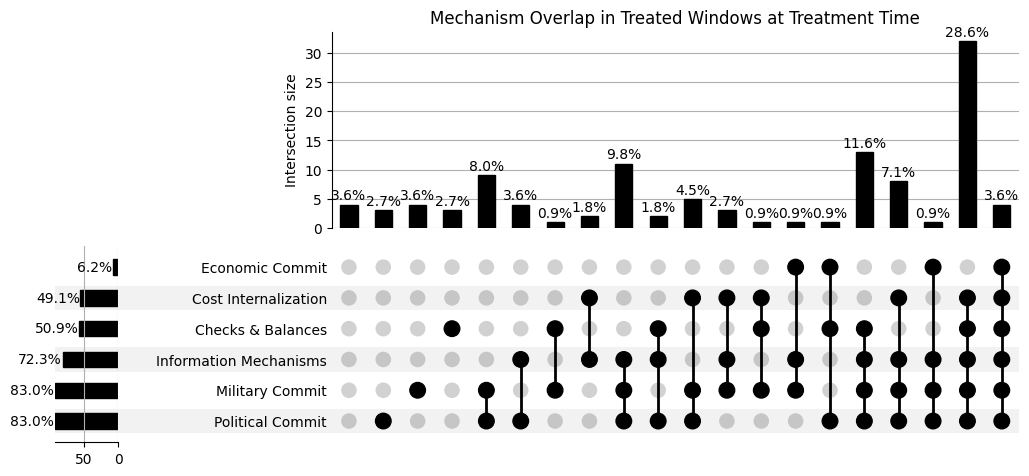

In [32]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from upsetplot import UpSet
import matplotlib.pyplot as plt

# Solo una fila por treated window en t=0
df0 = df_clean[(df_clean['is_treated_window']==1) & (df_clean['window_t']==0)]
df0 = df0.drop_duplicates(subset=['window_id'])

mecha_cols = [
    'has_info_mecha',
    'has_commit_pol_mecha',
    'has_commit_econ_mecha',
    'has_commit_mil_mecha',
    'has_cost_mecha',
    'has_balancing_mecha'
]

label_map = {
    'has_info_mecha': 'Information Mechanisms',
    'has_commit_pol_mecha': 'Political Commit',
    'has_commit_econ_mecha': 'Economic Commit',
    'has_commit_mil_mecha': 'Military Commit',
    'has_cost_mecha': 'Cost Internalization',
    'has_balancing_mecha': 'Checks & Balances'
}

# Creamos MultiIndex booleano
df_upset = df0.set_index(mecha_cols)['window_id'].notnull()

# Renombrar niveles del MtiIndex
df_upset.index = df_upset.index.rename(
    [label_map[col] for col in mecha_cols]
)
#df_upset = df0.set_index(mecha_cols)['window_id'].notnull()

plt.figure(figsize=(12,6))
UpSet(df_upset, subset_size='count', show_percentages=True).plot()
plt.title("Mechanism Overlap in Treated Windows at Treatment Time")
plt.show()
